# NB6: 绩效分析与可视化

## 目的
> 汇总NB2-NB4所有策略的绩效数据，用多维度可视化呈现全貌。面试时可以直接引用本Notebook的图表。

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

已加载: 35,064 条 BTC/USDT 1h K线


---
## 1. 重建所有策略信号

In [3]:
# --- 回测函数 ---
def backtest(df, fee=0.001, slippage=0.0005):
    data = df.copy()
    data['cost'] = data['signal'].diff().abs() * (fee + slippage)
    data['strategy_returns'] = data['signal'].shift(1) * data['returns'] - data['cost']
    data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()
    data['cumulative_market'] = (1 + data['returns']).cumprod()
    return data

def calc_metrics(data, name):
    ret = data['strategy_returns'].dropna()
    cum = data['cumulative_strategy'].dropna()
    total = cum.iloc[-1] / cum.iloc[0] - 1
    n = len(ret)
    annual_ret = (1 + total) ** (8760 / n) - 1
    annual_vol = ret.std() * np.sqrt(8760)
    sharpe = annual_ret / annual_vol if annual_vol != 0 else 0
    peak = cum.cummax()
    max_dd = ((cum - peak) / peak).min()
    trades = data['signal'].diff().abs().sum() / 2
    return {
        '策略': name, '总收益': total, '年化收益': annual_ret,
        '年化波动': annual_vol, '夏普比率': sharpe, '最大回撤': max_dd,
        '交易次数': int(trades),
    }

# --- 买入持有 ---
df_hold = df.copy()
df_hold['signal'] = 1.0
df_hold_bt = backtest(df_hold)

# --- NB2: 双均线交叉 ---
df_ma = df.copy()
ma_s = df_ma['close'].rolling(20).mean()
ma_l = df_ma['close'].rolling(60).mean()
df_ma['signal'] = 0.0
df_ma.loc[ma_s > ma_l, 'signal'] = 1.0
df_ma_bt = backtest(df_ma)

# --- NB2: RSI ---
df_rsi = df.copy()
delta = df_rsi['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df_rsi['rsi'] = 100 - (100 / (1 + rs))
df_rsi['signal'] = np.nan
df_rsi.loc[df_rsi['rsi'] <= 30, 'signal'] = 1.0
df_rsi.loc[df_rsi['rsi'] >= 70, 'signal'] = 0.0
df_rsi['signal'] = df_rsi['signal'].ffill().fillna(0)
df_rsi_bt = backtest(df_rsi)

# --- NB2: 布林带 ---
df_bb = df.copy()
bb_mid = df_bb['close'].rolling(20).mean()
bb_std = df_bb['close'].rolling(20).std()
df_bb['signal'] = np.nan
df_bb.loc[df_bb['close'] < bb_mid - 2 * bb_std, 'signal'] = 1.0
df_bb.loc[df_bb['close'] > bb_mid + 2 * bb_std, 'signal'] = 0.0
df_bb['signal'] = df_bb['signal'].ffill().fillna(0)
df_bb_bt = backtest(df_bb)

# --- NB3: Z-score ---
df_zs = df.copy()
rm = df_zs['close'].rolling(168).mean()
rs_std = df_zs['close'].rolling(168).std()
df_zs['zscore'] = (df_zs['close'] - rm) / rs_std
df_zs['signal'] = np.nan
df_zs.loc[df_zs['zscore'] <= -1.5, 'signal'] = 1.0
df_zs.loc[df_zs['zscore'] >= 0, 'signal'] = 0.0
df_zs['signal'] = df_zs['signal'].ffill().fillna(0)
df_zs_bt = backtest(df_zs)

all_results = [
    calc_metrics(df_hold_bt, '买入持有'),
    calc_metrics(df_ma_bt, '双均线交叉'),
    calc_metrics(df_rsi_bt, 'RSI超买超卖'),
    calc_metrics(df_bb_bt, '布林带突破'),
    calc_metrics(df_zs_bt, 'Z-score均值回归'),
]

df_summary = pd.DataFrame(all_results).set_index('策略')
print("所有策略重建完成")

所有策略重建完成


---
## 2. 绩效总览表

In [4]:
display = df_summary.copy()
for col in ['总收益', '年化收益', '年化波动', '最大回撤']:
    display[col] = display[col].apply(lambda x: f"{x:.1%}")
display['夏普比率'] = display['夏普比率'].apply(lambda x: f"{x:.2f}")
display

,总收益,年化收益,年化波动,夏普比率,最大回撤,交易次数
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,0
双均线交叉,-35.2%,-10.3%,42.0%,-0.24,-76.4%,362
RSI超买超卖,-77.0%,-30.8%,45.6%,-0.68,-84.2%,388
布林带突破,-42.8%,-13.0%,47.8%,-0.27,-66.8%,418
Z-score均值回归,17.4%,4.1%,41.8%,0.10,-50.6%,143


---
## 3. 多维度可视化

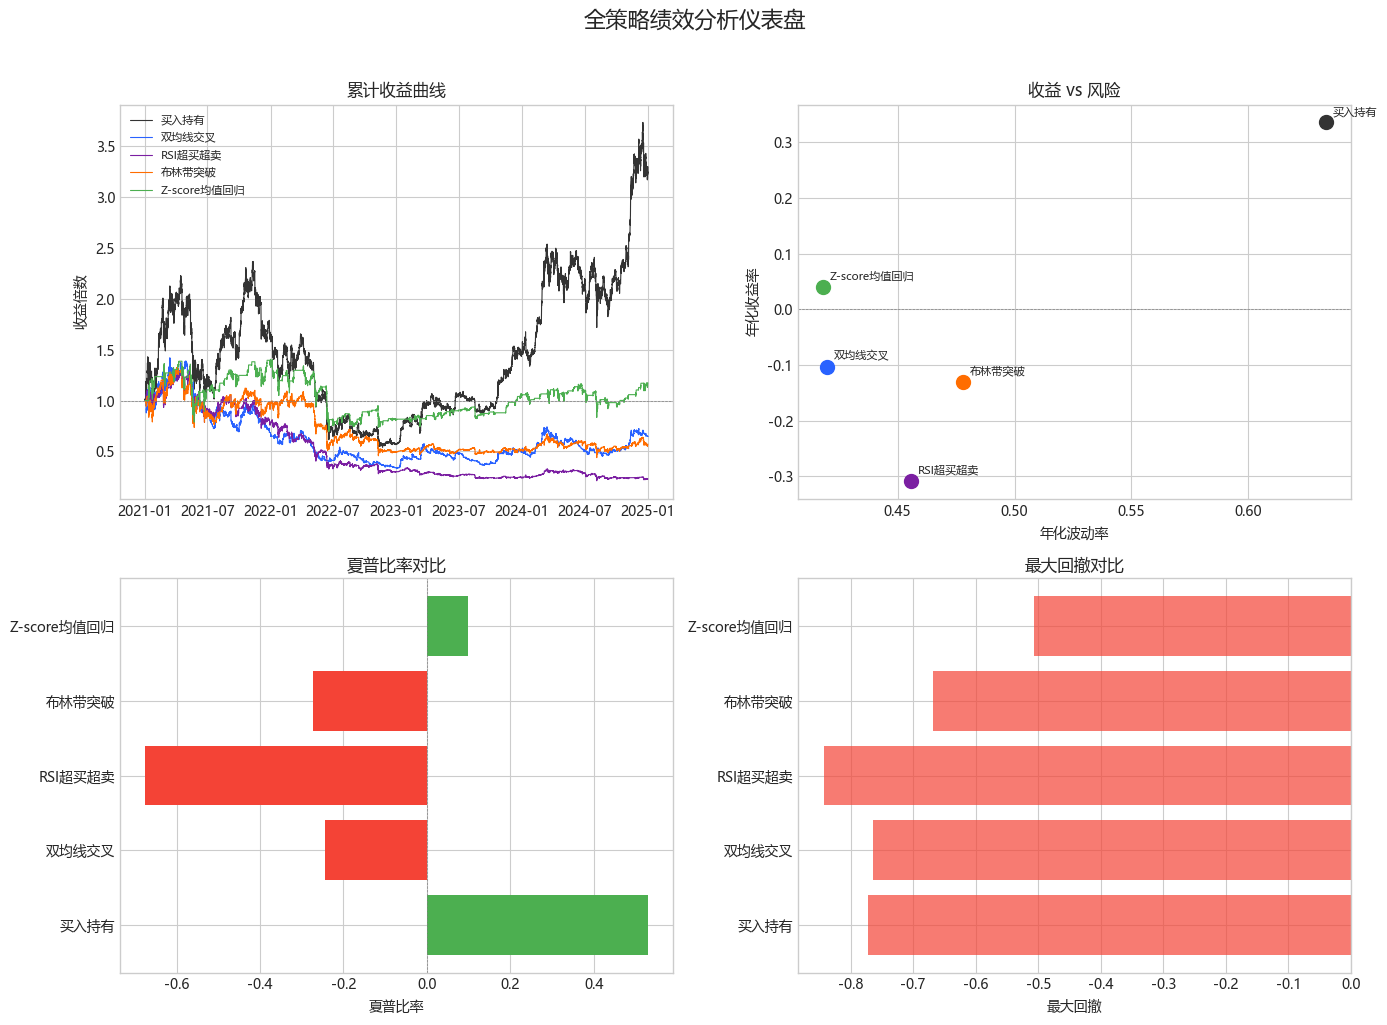

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

strategies = ['买入持有', '双均线交叉', 'RSI超买超卖', '布林带突破', 'Z-score均值回归']
colors = ['#333333', '#2962FF', '#7B1FA2', '#FF6D00', '#4CAF50']

# --- 图1: 累计收益曲线 ---
all_bt = [df_hold_bt, df_ma_bt, df_rsi_bt, df_bb_bt, df_zs_bt]
for bt, color, name in zip(all_bt, colors, strategies):
    axes[0,0].plot(bt.index, bt['cumulative_strategy'], linewidth=0.8, color=color, label=name)
axes[0,0].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[0,0].set_title('累计收益曲线')
axes[0,0].set_ylabel('收益倍数')
axes[0,0].legend(fontsize=8)

# --- 图2: 收益 vs 风险散点图 ---
for i, name in enumerate(strategies):
    row = df_summary.loc[name]
    axes[0,1].scatter(row['年化波动'], row['年化收益'], c=colors[i], s=100, zorder=5)
    axes[0,1].annotate(name, (row['年化波动'], row['年化收益']), fontsize=8,
                        xytext=(5, 5), textcoords='offset points')
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[0,1].set_title('收益 vs 风险')
axes[0,1].set_xlabel('年化波动率')
axes[0,1].set_ylabel('年化收益率')

# --- 图3: 夏普比率对比 ---
sharpe_vals = df_summary['夏普比率']
bar_colors = ['#4CAF50' if v > 0 else '#F44336' for v in sharpe_vals]
axes[1,0].barh(sharpe_vals.index, sharpe_vals.values, color=bar_colors)
axes[1,0].axvline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1,0].set_title('夏普比率对比')
axes[1,0].set_xlabel('夏普比率')

# --- 图4: 最大回撤对比 ---
dd_vals = df_summary['最大回撤']
axes[1,1].barh(dd_vals.index, dd_vals.values, color='#F44336', alpha=0.7)
axes[1,1].set_title('最大回撤对比')
axes[1,1].set_xlabel('最大回撤')

plt.suptitle('全策略绩效分析仪表盘', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 小结

**仪表盘关键读数**
1. 收益散点图中，只有买入持有和Z-score在第一象限（正收益），其余都在负收益区
2. Z-score是唯一一个在降低波动率的同时保持正收益的策略（波动42% vs 持有63%）
3. 回撤方面，Z-score的-50.6%好于买入持有的-77.2%，风控效果明显

**策略排名（风险调整后）**
1. 买入持有：夏普0.53，绝对收益最高但回撤最大
2. Z-score均值回归：夏普0.10，唯一有正向alpha的主动策略
3. 其余策略：夏普均为负，不值得交易